In [1]:
import polars as pl
pl.Config.set_fmt_str_lengths(100)

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import numpy as np

In [2]:
AJ = pl.scan_csv("../test_data/af2/positive_dimers/predictions/*/interfaces.csv").collect()
AJ

jobs,model_used,interface,iptm_ptm,iptm,ptm,confidence_score,pDockQ/mpDockQ,average_interface_pae,interface_average_plddt,interface_num_intf_residues,interface_polar,interface_hydrophobic,interface_charged,interface_contact_pairs,interface_score,interface_pDockQ2,interface_ipSAE,interface_LIS,interface_hb,interface_sb,interface_ss,interface_sc,interface_area,interface_solv_en,voroif_pgoodness,voroif_area,voroif_pgoodness_average,voroif_pcadscore,voroif_num_of_residues,voroif_residue_pcadscore
str,str,str,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""O00189+Q9UPM8""","""model_4_multimer_v3_pred_0""","""7_8""",0.666942,0.690995,0.570728,0.666942,0.455883,10.661429,79.55449,98,0.285714,0.346939,0.265306,105,160.794683,0.090513,0.573806,0.270164,7,4,0,0.366366,2102.328067,-21.670822,991.319822,2106.165704,0.470675,0.29272,136.0,0.447343
"""O00212+Q9HAD4""","""model_2_multimer_v3_pred_0""","""9_A""",0.305816,0.226044,0.624905,0.305816,0.177684,21.273077,70.788704,54,0.166667,0.333333,0.351852,65,128.333786,0.011407,0.0,0.0,4,1,0,0.306314,892.164076,-10.966267,-1413.831543,929.903032,-1.520407,0.014764,62.0,0.027054
"""O00541+Q14684""","""model_2_multimer_v3_pred_0""","""9_A""",0.240661,0.194502,0.425297,0.240661,0.022708,25.344444,58.58,14,0.142857,0.5,0.285714,9,55.899526,0.009147,0.0,0.0,0,0,0,0.324257,182.977145,-1.501399,-271.439717,194.333226,-1.396775,0.018081,24.0,0.028809
"""O14544+Q86XK2""","""model_4_multimer_v3_pred_0""","""7_8""",0.317169,0.254619,0.567369,0.317169,0.20552,22.955556,58.705385,143,0.34965,0.272727,0.258741,180,132.39664,0.009826,0.0,0.0,24,14,0,0.254624,2850.764293,-17.977921,-5446.509053,2923.238568,-1.863176,0.008393,181.0,0.061383
"""O14641+P10515""","""model_1_multimer_v3_pred_0""","""A_B""",0.210637,0.190665,0.290526,0.210637,0.209324,27.877288,53.817569,181,0.265193,0.298343,0.298343,295,132.919817,0.008662,0.0,0.0,38,2,0,0.189665,3097.757942,-24.110322,-8961.620682,3495.789247,-2.563547,0.002627,206.0,0.004955
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q96PC5+Q9Y4K3""","""model_3_multimer_v3_pred_0""","""8_9""",0.339977,0.351389,0.294328,0.339977,0.457056,21.873691,62.863679,212,0.287736,0.377358,0.264151,363,160.925149,0.013342,0.092324,0.228155,24,14,0,0.329036,4234.312075,-47.393888,-5340.549107,4670.914626,-1.143363,0.027324,238.0,0.209772
"""Q96ST3+P12755""","""model_3_multimer_v3_pred_0""","""8_9""",0.23359,0.195627,0.385442,0.23359,0.120125,29.969906,47.076533,199,0.286432,0.386935,0.21608,319,117.869784,0.008248,0.0,0.0,25,0,0,0.088317,3896.378575,-41.326636,-11098.784718,4318.722581,-2.569923,0.002599,231.0,0.007031
"""Q99440+Q99871""","""model_4_multimer_v3_pred_0""","""7_8""",0.34162,0.325911,0.404456,0.34162,0.056104,15.379141,43.859802,101,0.306931,0.485149,0.138614,163,97.02611,0.01202,0.01404,0.119339,2,0,0,0.291726,1686.969092,-29.547448,-2948.651602,1822.097518,-1.618273,0.01257,107.0,0.038089


In [3]:
CCP4 = pl.read_csv("../test_data/af2/positive_dimers/benchmarks/CCP4.csv")
CCP4

complex,interface_name,int_area,pvalue,int_solv_en,hb,sb
str,str,f64,f64,f64,i64,i64
"""O00189+Q9UPM8""","""7_8""",2102.27,0.23,-21.94,7,4
"""O00212+Q9HAD4""","""9_A""",892.16,0.23,-10.97,4,1
"""O00541+Q14684""","""9_A""",182.98,0.49,-1.5,0,0
"""O14544+Q86XK2""","""7_8""",2850.76,0.5,-18.04,24,14
"""O14641+P10515""","""A_B""",3097.67,0.45,-24.4,38,2
…,…,…,…,…,…,…
"""Q9UQ80+P06400""","""8_9""",1689.45,0.45,-6.7,6,5
"""Q9UQB8+O14910""","""8_9""",688.14,0.73,-1.63,6,0
"""Q9Y2D8+Q96JH7""","""A_B""",6598.27,0.63,-40.99,50,24


In [4]:
column_mapping = {
        "interface_hb": "hb",
        "interface_sb": "sb",
        "interface_solv_en": "int_solv_en",
        "interface_area": "int_area"}

In [5]:
#aj_cols = list(column_mapping.values())
#CCP4 = CCP4.select(aj_cols)
    
rename_map = {v: k for k, v in column_mapping.items() if k != v}
if rename_map:
    CCP4 = CCP4.rename(rename_map)

In [6]:
df = AJ.join(CCP4, left_on="jobs", right_on="complex")
df

jobs,model_used,interface,iptm_ptm,iptm,ptm,confidence_score,pDockQ/mpDockQ,average_interface_pae,interface_average_plddt,interface_num_intf_residues,interface_polar,interface_hydrophobic,interface_charged,interface_contact_pairs,interface_score,interface_pDockQ2,interface_ipSAE,interface_LIS,interface_hb,interface_sb,interface_ss,interface_sc,interface_area,interface_solv_en,voroif_pgoodness,voroif_area,voroif_pgoodness_average,voroif_pcadscore,voroif_num_of_residues,voroif_residue_pcadscore,interface_name,interface_area_right,pvalue,interface_solv_en_right,interface_hb_right,interface_sb_right
str,str,str,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,i64,i64
"""O00189+Q9UPM8""","""model_4_multimer_v3_pred_0""","""7_8""",0.666942,0.690995,0.570728,0.666942,0.455883,10.661429,79.55449,98,0.285714,0.346939,0.265306,105,160.794683,0.090513,0.573806,0.270164,7,4,0,0.366366,2102.328067,-21.670822,991.319822,2106.165704,0.470675,0.29272,136.0,0.447343,"""7_8""",2102.27,0.23,-21.94,7,4
"""O00212+Q9HAD4""","""model_2_multimer_v3_pred_0""","""9_A""",0.305816,0.226044,0.624905,0.305816,0.177684,21.273077,70.788704,54,0.166667,0.333333,0.351852,65,128.333786,0.011407,0.0,0.0,4,1,0,0.306314,892.164076,-10.966267,-1413.831543,929.903032,-1.520407,0.014764,62.0,0.027054,"""9_A""",892.16,0.23,-10.97,4,1
"""O00541+Q14684""","""model_2_multimer_v3_pred_0""","""9_A""",0.240661,0.194502,0.425297,0.240661,0.022708,25.344444,58.58,14,0.142857,0.5,0.285714,9,55.899526,0.009147,0.0,0.0,0,0,0,0.324257,182.977145,-1.501399,-271.439717,194.333226,-1.396775,0.018081,24.0,0.028809,"""9_A""",182.98,0.49,-1.5,0,0
"""O14544+Q86XK2""","""model_4_multimer_v3_pred_0""","""7_8""",0.317169,0.254619,0.567369,0.317169,0.20552,22.955556,58.705385,143,0.34965,0.272727,0.258741,180,132.39664,0.009826,0.0,0.0,24,14,0,0.254624,2850.764293,-17.977921,-5446.509053,2923.238568,-1.863176,0.008393,181.0,0.061383,"""7_8""",2850.76,0.5,-18.04,24,14
"""O14641+P10515""","""model_1_multimer_v3_pred_0""","""A_B""",0.210637,0.190665,0.290526,0.210637,0.209324,27.877288,53.817569,181,0.265193,0.298343,0.298343,295,132.919817,0.008662,0.0,0.0,38,2,0,0.189665,3097.757942,-24.110322,-8961.620682,3495.789247,-2.563547,0.002627,206.0,0.004955,"""A_B""",3097.67,0.45,-24.4,38,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q96PC5+Q9Y4K3""","""model_3_multimer_v3_pred_0""","""8_9""",0.339977,0.351389,0.294328,0.339977,0.457056,21.873691,62.863679,212,0.287736,0.377358,0.264151,363,160.925149,0.013342,0.092324,0.228155,24,14,0,0.329036,4234.312075,-47.393888,-5340.549107,4670.914626,-1.143363,0.027324,238.0,0.209772,"""8_9""",4234.31,0.19,-48.3,24,14
"""Q96ST3+P12755""","""model_3_multimer_v3_pred_0""","""8_9""",0.23359,0.195627,0.385442,0.23359,0.120125,29.969906,47.076533,199,0.286432,0.386935,0.21608,319,117.869784,0.008248,0.0,0.0,25,0,0,0.088317,3896.378575,-41.326636,-11098.784718,4318.722581,-2.569923,0.002599,231.0,0.007031,"""8_9""",3896.38,0.32,-41.33,25,0
"""Q99440+Q99871""","""model_4_multimer_v3_pred_0""","""7_8""",0.34162,0.325911,0.404456,0.34162,0.056104,15.379141,43.859802,101,0.306931,0.485149,0.138614,163,97.02611,0.01202,0.01404,0.119339,2,0,0,0.291726,1686.969092,-29.547448,-2948.651602,1822.097518,-1.618273,0.01257,107.0,0.038089,"""7_8""",1686.97,0.17,-29.55,2,0


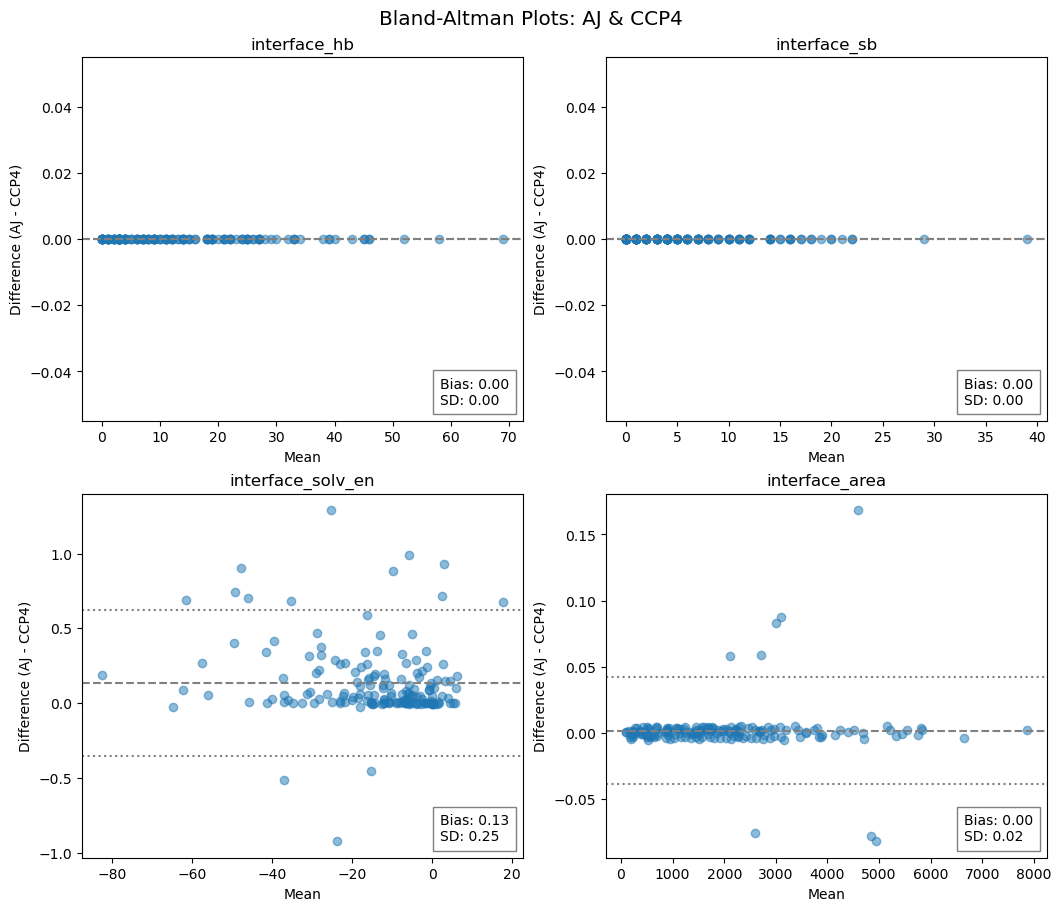

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(10.5, 9), layout="constrained")
n = 0

for score in column_mapping.keys():
    # Get matched columns
    col_aj = score
    col_ccp4 = score + "_right"
    
    # Extract data
    data_aj = df[col_aj].to_numpy()
    data_ccp4 = df[col_ccp4].to_numpy()
    
    # Bland-Altman stats
    means = (data_aj + data_ccp4) / 2
    diffs = data_aj - data_ccp4
    bias = np.mean(diffs)
    sd = np.std(diffs, ddof=1)
    loa_u = bias + 1.96 * sd
    loa_l = bias - 1.96 * sd
    
    # Plot
    ax = axs.flat[n]
    ax.scatter(x=means, y=diffs, alpha=0.5)
    
    # Lines
    ax.axhline(bias, color='gray', linestyle='--')
    ax.axhline(loa_u, color='gray', linestyle=':')
    ax.axhline(loa_l, color='gray', linestyle=':')
    
    # Annotations
    text_stats = f"Bias: {bias:.2f}\nSD: {sd:.2f}"
    text_box = AnchoredText(text_stats, frameon=True, loc=4, pad=0.5)
    plt.setp(text_box.patch, facecolor='white', alpha=0.5)
    ax.add_artist(text_box)
    
    ax.set_title(score)
    ax.set_xlabel('Mean')
    ax.set_ylabel('Difference (AJ - CCP4)')
        
    n += 1

fig.suptitle("Bland-Altman Plots: AJ & CCP4", fontsize="x-large")
fig.savefig("figures/Bland_Altman_AJ_CCP4.png")
plt.show()

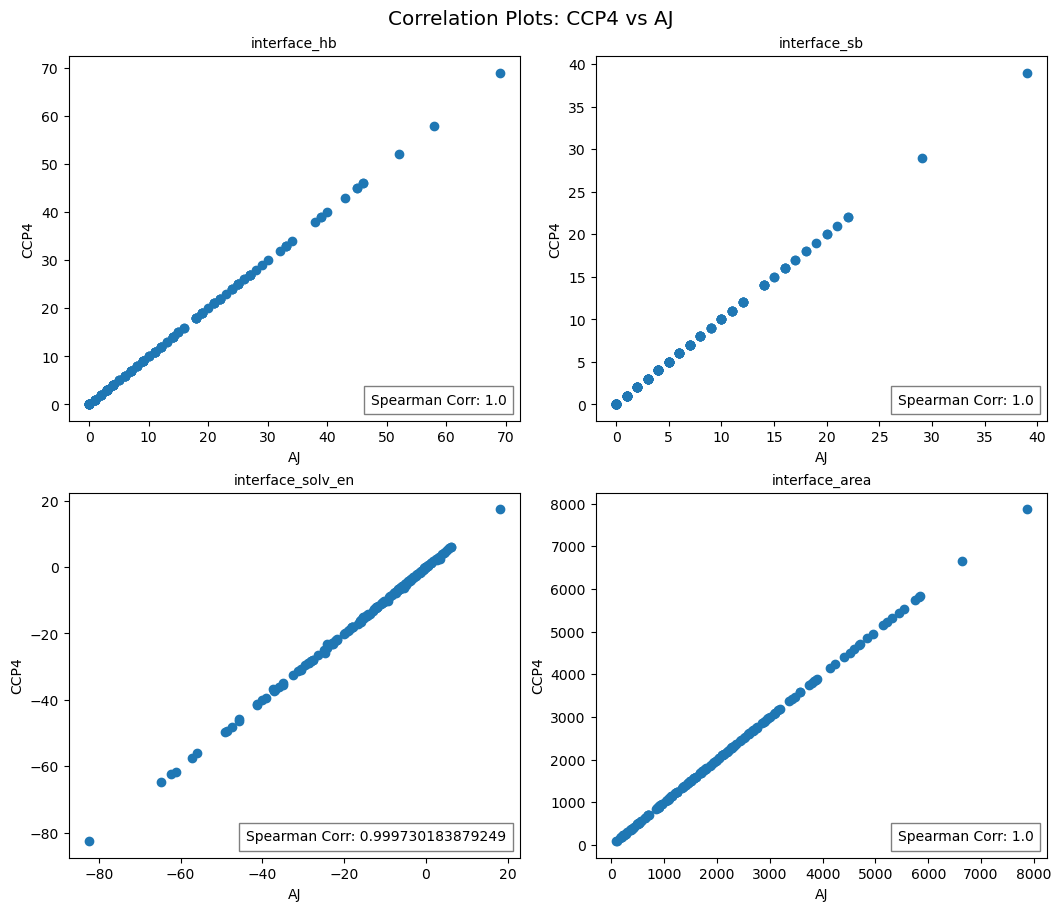

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(10.5, 9), layout="constrained")
n = 0

for score in column_mapping.keys():
    axs.flat[n].scatter(x=df[score], y=df[score+"_right"])
    axs.flat[n].set_title(score, fontsize='medium', loc='center')
    
    corr = df.select(pl.corr(score, score+"_right", method="spearman")).item()
    text_box = AnchoredText(f"Spearman Corr: {corr}", frameon=True, loc=4, pad=0.5)
    plt.setp(text_box.patch, facecolor='white', alpha=0.5)
    axs.flat[n].add_artist(text_box)
    axs.flat[n].set_xlabel('AJ')
    axs.flat[n].set_ylabel('CCP4')
    
    n += 1

#fig.supxlabel('AJ', fontsize='large')
#fig.supylabel('CCP4', fontsize='large')
fig.suptitle("Correlation Plots: CCP4 vs AJ", fontsize="x-large")
fig.savefig('figures/Correlation_CCP4_vs_AJ.png')

plt.show()

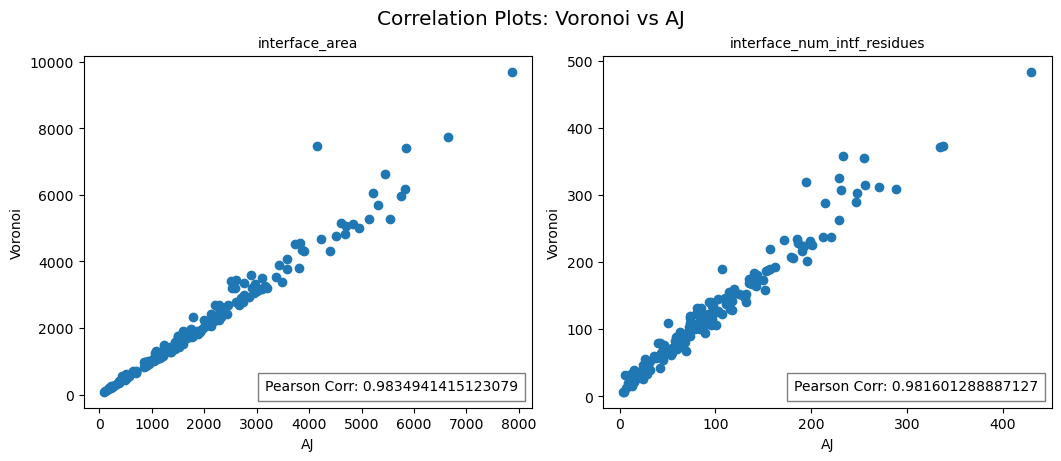

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.5), layout="constrained")
voronoi = {
        "interface_area": "voroif_area",
        "interface_num_intf_residues": "voroif_num_of_residues"}

n = 0

for score in voronoi.keys():
    axs.flat[n].scatter(x=AJ[score], y=AJ[voronoi[score]])
    axs.flat[n].set_title(score, fontsize='medium', loc='center')
    
    corr = df.select(pl.corr(score, voronoi[score], method="pearson")).item()
    text_box = AnchoredText(f"Pearson Corr: {corr}", frameon=True, loc=4, pad=0.5)
    plt.setp(text_box.patch, facecolor='white', alpha=0.5)
    axs.flat[n].add_artist(text_box)
    axs.flat[n].set_xlabel('AJ')
    axs.flat[n].set_ylabel('Voronoi')
    
    n += 1

fig.suptitle("Correlation Plots: Voronoi vs AJ", fontsize="x-large")
fig.savefig('figures/Correlation_voronoi_vs_AJ.png')

plt.show()